In [10]:
# Imports
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [11]:
feature_df = pd.read_csv('feature_data.csv')
topo_features = [ 
    'source_degree', 'source_weighted_degree', 'source_avg_distance', 
    'target_degree', 'target_weighted_degree', 'target_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index','weight', 'distance']
wthr_features = ['FHVEC', 'TG', 'TN', 'TX', 'T10N', 'SQ', 'DR', 'RH', 'RHX', 'VVX']    
X_topo = np.array(feature_df[topo_features])
X_wthr = np.array(feature_df[wthr_features])
X_comp = np.array(feature_df.drop(columns=['Disrupted']))
y = np.array(feature_df['Disrupted'])

In [14]:
def compare_models(X, y):
    # Split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

    # apply SMOTE to training set, create validation set
    smote = SMOTE(random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
    X_train_balanced, X_val_balanced, y_train_balanced, y_val_balanced = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42
    )
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_balanced)
    X_val_scaled = scaler.transform(X_val_balanced)
    X_test_scaled = scaler.transform(X_test)

    logres = LogisticRegression(random_state=42, class_weight='balanced')
    rf = RandomForestClassifier(random_state=42, class_weight='balanced')
    xgb = XGBClassifier(random_state=42, scale_pos_weight=1)
    
    classifiers = [logres, rf, xgb]
    for classifier in classifiers:
        # Fit the classifier
        classifier.fit(X_train_scaled, y_train_balanced)
        y_pred = classifier.predict(X_val_scaled)
        # Evaluate on the validation set
        print(f"Validation set evaluation for {classifier.__class__.__name__}:")
        print(f"Classifier: {classifier.__class__.__name__}")
        print(classification_report(y_val_balanced, y_pred))
        print(confusion_matrix(y_val_balanced, y_pred))
        print("\n")
        # Evaluate on the test set
        y_test_pred = classifier.predict(X_test_scaled)
        print(f"Test set evaluation for {classifier.__class__.__name__}:")
        print(classification_report(y_test, y_test_pred))
        cm_test = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disruption', 'Disruption'], yticklabels=['No Disruption', 'Disruption'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix (Test)')
        plt.show()

Validation set evaluation for LogisticRegression:
Classifier: LogisticRegression
              precision    recall  f1-score   support

       False       0.68      0.68      0.68    126838
        True       0.68      0.68      0.68    126763

    accuracy                           0.68    253601
   macro avg       0.68      0.68      0.68    253601
weighted avg       0.68      0.68      0.68    253601

[[85968 40870]
 [40090 86673]]


Test set evaluation for LogisticRegression:
              precision    recall  f1-score   support

       False       0.99      0.68      0.81    181064
        True       0.03      0.68      0.06      2773

    accuracy                           0.68    183837
   macro avg       0.51      0.68      0.43    183837
weighted avg       0.98      0.68      0.79    183837



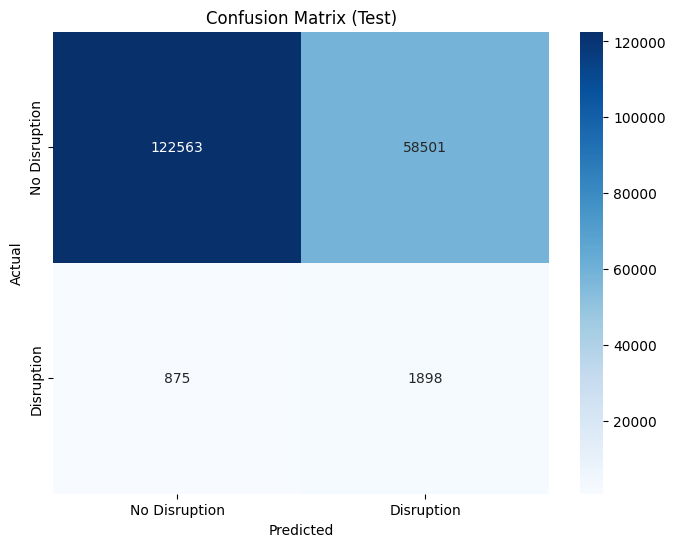

Validation set evaluation for RandomForestClassifier:
Classifier: RandomForestClassifier
              precision    recall  f1-score   support

       False       0.99      0.99      0.99    126838
        True       0.99      0.99      0.99    126763

    accuracy                           0.99    253601
   macro avg       0.99      0.99      0.99    253601
weighted avg       0.99      0.99      0.99    253601

[[125121   1717]
 [   768 125995]]


Test set evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99    181064
        True       0.25      0.29      0.27      2773

    accuracy                           0.98    183837
   macro avg       0.62      0.64      0.63    183837
weighted avg       0.98      0.98      0.98    183837



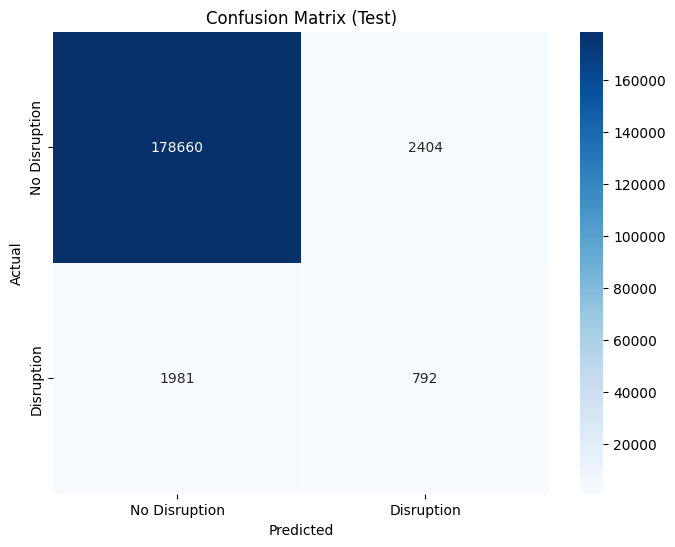

Validation set evaluation for XGBClassifier:
Classifier: XGBClassifier
              precision    recall  f1-score   support

       False       0.98      0.97      0.98    126838
        True       0.97      0.98      0.98    126763

    accuracy                           0.98    253601
   macro avg       0.98      0.98      0.98    253601
weighted avg       0.98      0.98      0.98    253601

[[123489   3349]
 [  2878 123885]]


Test set evaluation for XGBClassifier:
              precision    recall  f1-score   support

       False       0.99      0.97      0.98    181064
        True       0.19      0.40      0.26      2773

    accuracy                           0.97    183837
   macro avg       0.59      0.69      0.62    183837
weighted avg       0.98      0.97      0.97    183837



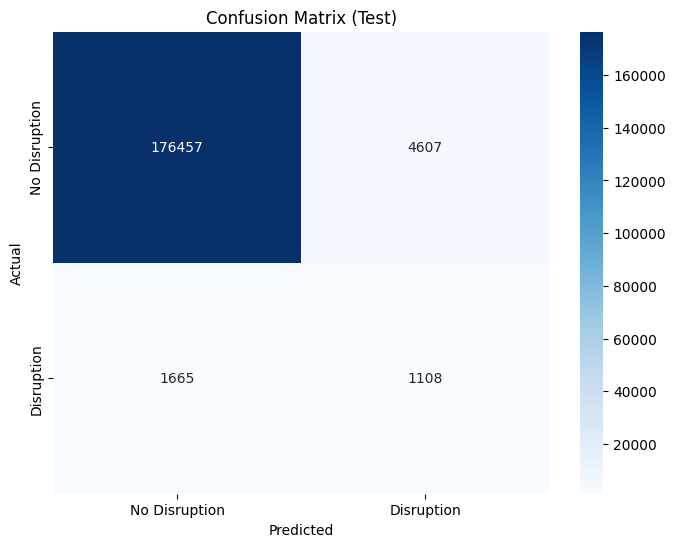

In [15]:
compare_models(X_topo, y)

Validation set evaluation for LogisticRegression:
Classifier: LogisticRegression
              precision    recall  f1-score   support

       False       0.72      0.56      0.63    126838
        True       0.64      0.78      0.70    126763

    accuracy                           0.67    253601
   macro avg       0.68      0.67      0.67    253601
weighted avg       0.68      0.67      0.67    253601

[[71239 55599]
 [27735 99028]]


Test set evaluation for LogisticRegression:
              precision    recall  f1-score   support

       False       0.99      0.56      0.72    181064
        True       0.03      0.77      0.05      2773

    accuracy                           0.57    183837
   macro avg       0.51      0.67      0.39    183837
weighted avg       0.98      0.57      0.71    183837



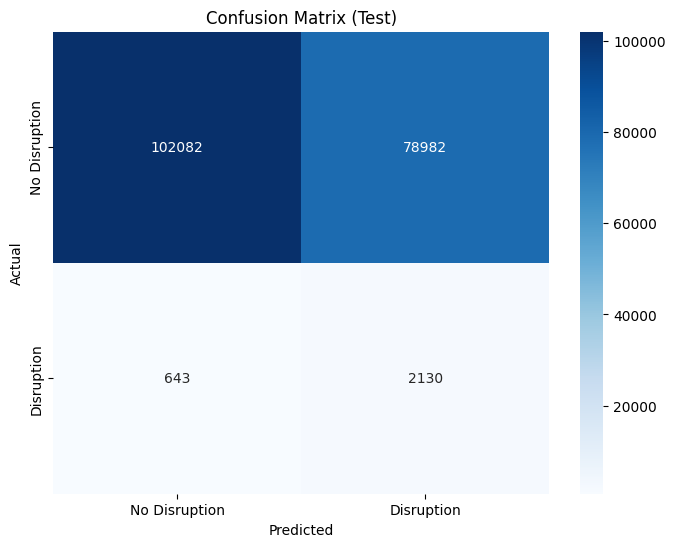

Validation set evaluation for RandomForestClassifier:
Classifier: RandomForestClassifier
              precision    recall  f1-score   support

       False       0.99      0.99      0.99    126838
        True       0.99      0.99      0.99    126763

    accuracy                           0.99    253601
   macro avg       0.99      0.99      0.99    253601
weighted avg       0.99      0.99      0.99    253601

[[125804   1034]
 [  1343 125420]]


Test set evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99    181064
        True       0.10      0.06      0.07      2773

    accuracy                           0.98    183837
   macro avg       0.54      0.53      0.53    183837
weighted avg       0.97      0.98      0.97    183837



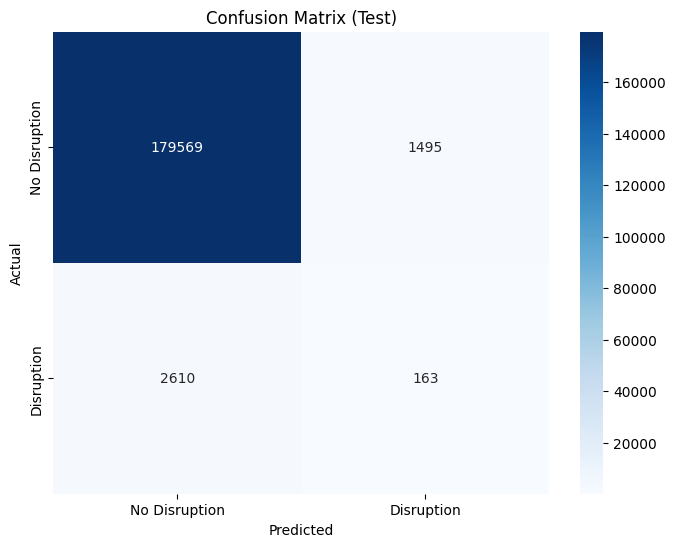

Validation set evaluation for XGBClassifier:
Classifier: XGBClassifier
              precision    recall  f1-score   support

       False       0.95      0.98      0.97    126838
        True       0.98      0.95      0.96    126763

    accuracy                           0.96    253601
   macro avg       0.97      0.96      0.96    253601
weighted avg       0.97      0.96      0.96    253601

[[124169   2669]
 [  6281 120482]]


Test set evaluation for XGBClassifier:
              precision    recall  f1-score   support

       False       0.99      0.98      0.98    181064
        True       0.12      0.18      0.14      2773

    accuracy                           0.97    183837
   macro avg       0.55      0.58      0.56    183837
weighted avg       0.97      0.97      0.97    183837



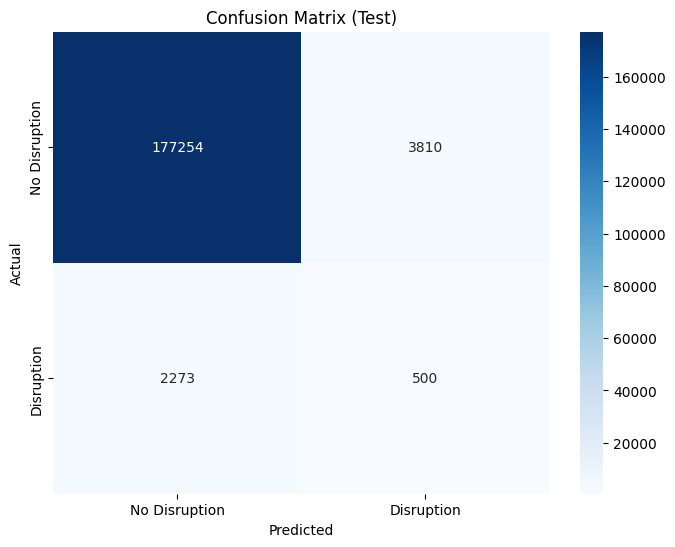

In [16]:
compare_models(X_wthr, y)

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation set evaluation for LogisticRegression:
Classifier: LogisticRegression
              precision    recall  f1-score   support

       False       0.79      0.72      0.75    126838
        True       0.74      0.80      0.77    126763

    accuracy                           0.76    253601
   macro avg       0.76      0.76      0.76    253601
weighted avg       0.76      0.76      0.76    253601

[[ 90958  35880]
 [ 24805 101958]]


Test set evaluation for LogisticRegression:
              precision    recall  f1-score   support

       False       1.00      0.72      0.84    181064
        True       0.04      0.80      0.08      2773

    accuracy                           0.72    183837
   macro avg       0.52      0.76      0.46    183837
weighted avg       0.98      0.72      0.82    183837



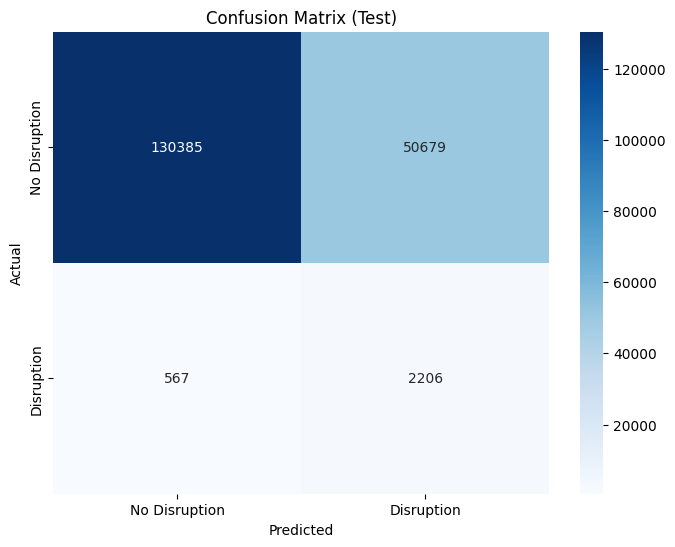

Validation set evaluation for RandomForestClassifier:
Classifier: RandomForestClassifier
              precision    recall  f1-score   support

       False       1.00      0.99      0.99    126838
        True       0.99      1.00      0.99    126763

    accuracy                           0.99    253601
   macro avg       0.99      0.99      0.99    253601
weighted avg       0.99      0.99      0.99    253601

[[125124   1714]
 [   567 126196]]


Test set evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99    181064
        True       0.26      0.30      0.28      2773

    accuracy                           0.98    183837
   macro avg       0.62      0.64      0.63    183837
weighted avg       0.98      0.98      0.98    183837



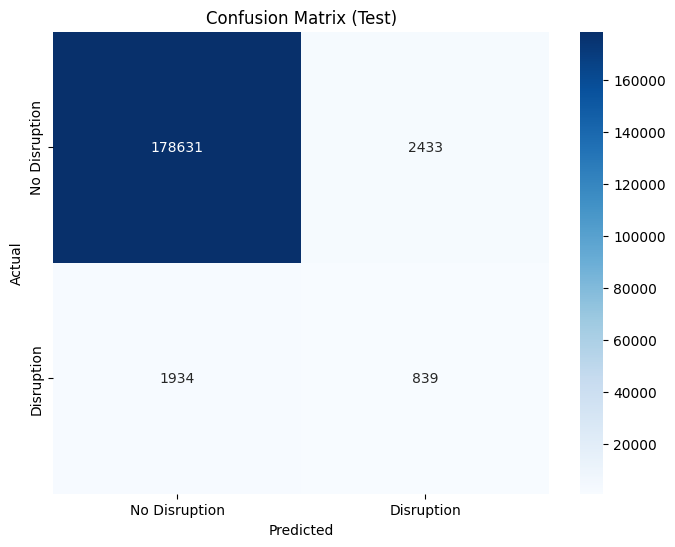

Validation set evaluation for XGBClassifier:
Classifier: XGBClassifier
              precision    recall  f1-score   support

       False       0.99      0.98      0.98    126838
        True       0.98      0.99      0.98    126763

    accuracy                           0.98    253601
   macro avg       0.98      0.98      0.98    253601
weighted avg       0.98      0.98      0.98    253601

[[124386   2452]
 [  1755 125008]]


Test set evaluation for XGBClassifier:
              precision    recall  f1-score   support

       False       0.99      0.98      0.99    181064
        True       0.22      0.35      0.27      2773

    accuracy                           0.97    183837
   macro avg       0.61      0.67      0.63    183837
weighted avg       0.98      0.97      0.97    183837



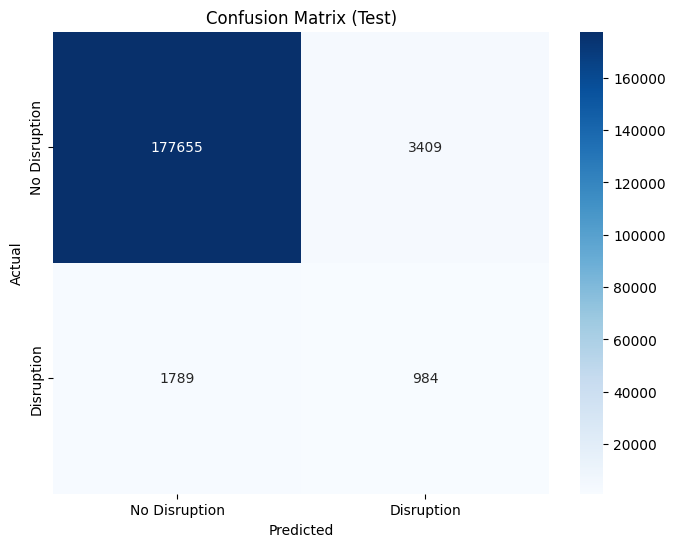

In [17]:
compare_models(X_comp, y)